In [234]:
import warnings 
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score
from sklearn.metrics import precision_score, f1_score, auc, roc_curve,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

In [271]:
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 
from patsy import dmatrices
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt  

In [236]:
from sklearn.neighbors import KNeighborsClassifier
NNH = KNeighborsClassifier(n_neighbors= 21)
from sklearn.naive_bayes import MultinomialNB

In [316]:
from sklearn import preprocessing
from itertools import cycle
from sklearn import svm, datasets
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from scipy import interp
from sklearn.metrics import classification_report


## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

## Question 1

Import the data set and print 10 random rows from the data set

In [238]:
colnames = ['sepal length in cm ','sepal width in cm', 'petal length in cm', 'petal width in cm', 'class']

In [239]:
iris_df = pd.read_csv("iris.data", names= colnames)
iris_df.head(5)

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [240]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal length in cm     150 non-null float64
sepal width in cm      150 non-null float64
petal length in cm     150 non-null float64
petal width in cm      150 non-null float64
class                  150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [241]:
#There are no missing values
iris_df.isnull().values.any()

False

## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

In [242]:
#Making Class column as category from int
iris_df['class'] = iris_df['class'].astype('category').cat.codes

In [243]:
iris_df['class'].unique()

array([0, 1, 2], dtype=int64)

## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

In [244]:
#print("Correlation between sepal width in cm & class" , iris_df['sepal length in cm'].corr(iris_df['class']))
print("Correlation between sepal width in cm & class" , iris_df['sepal width in cm'].corr(iris_df['class']))
print("Correlation between petal length in cm & class" ,iris_df['petal length in cm'].corr(iris_df['class']))
print("Correlation between petal width in cm & class" ,iris_df['petal width in cm'].corr(iris_df['class']))

Correlation between sepal width in cm & class -0.4194462002600274
Correlation between petal length in cm & class 0.9490425448523333
Correlation between petal width in cm & class 0.9564638238016165


Ans) Since no independent variable with target variable have a correlation in the range of -0.1 to 0.1, hence I am not dropping any columns.

## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [245]:
#print("Variance of sepal length in cm" , iris_df['sepal length in cm'].var())
print("Variance of sepal width in cm" , iris_df['sepal width in cm'].var())

Variance of sepal width in cm 0.18800402684563763


In [246]:
print("Variance of petal width in cm" ,iris_df['petal width in cm'].var())

Variance of petal width in cm 0.5824143176733784


In [247]:
print("Variance of petal length in cm" ,iris_df['petal length in cm'].var())

Variance of petal length in cm 3.1131794183445156


Ans) Since no independent variable's variance is almost 0, hence dropping no columns

## Question 6

*Plot the scatter matrix for all the variables.*

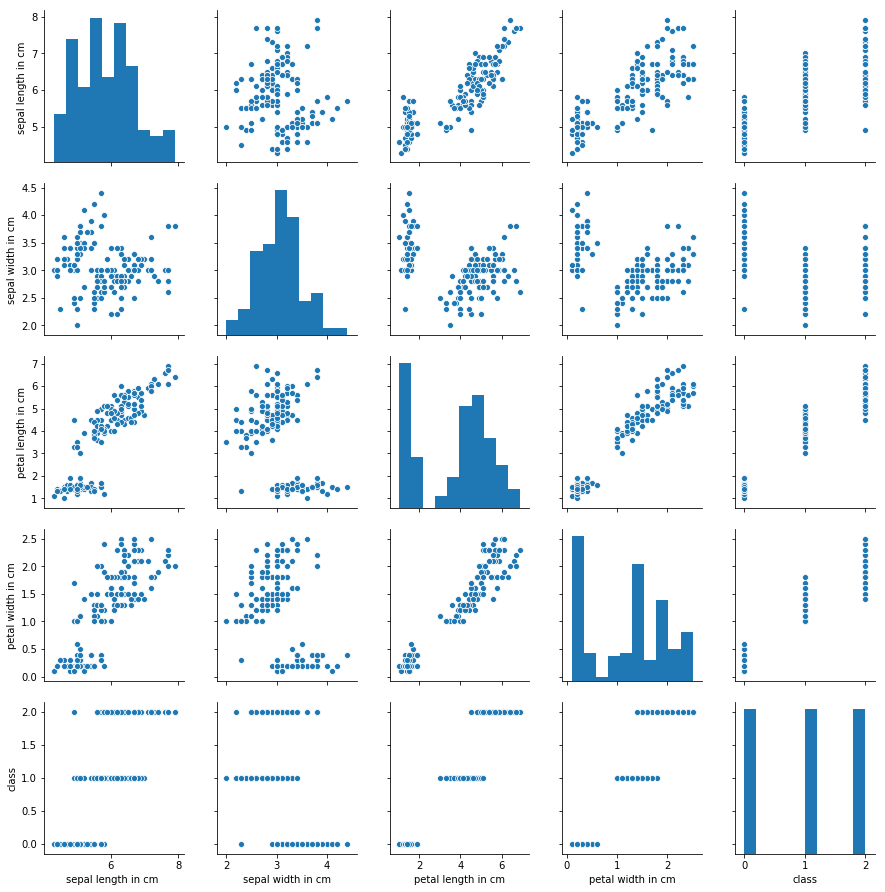

In [248]:
# Pairplot using sns
sns.pairplot(iris_df)

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [249]:
X = X.apply(zscore) 

In [250]:
y = iris_df[["class"]]

In [251]:
y = pd.get_dummies(y, drop_first=True)

In [252]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [253]:
Kvalues = [3,5,9]

for i in Kvalues:  
    NNH = KNeighborsClassifier(n_neighbors=i)
    NNH.fit(X_train, y_train)
    ypred2 = NNH.predict(X_test)
    testaccuracy=metrics.accuracy_score(y_test,ypred2)
    print("Accuracy Score(KValues =",i,")",testaccuracy)

Accuracy Score(KValues = 3 ) 0.8666666666666667
Accuracy Score(KValues = 5 ) 0.9
Accuracy Score(KValues = 9 ) 0.9


## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [285]:
MSE= np.arange(0,10, dtype=np.float)

In [286]:
Kvalues = np.arange(1,20,2)
j=0
for i in Kvalues:  
    NNH = KNeighborsClassifier(n_neighbors=i)
    NNH.fit(X_train, y_train)
    ypred2 = NNH.predict(X_test)
    #Calculating testaccuracy
    testaccuracy=metrics.accuracy_score(y_test,ypred2)
     #Calculating Misclassification error 
    MSE[j] = 1 - testaccuracy
    print("Misclassification error(KValues =",i,")",MSE[j])
    j=j+1

Misclassification error(KValues = 1 ) 0.09999999999999998
Misclassification error(KValues = 3 ) 0.1333333333333333
Misclassification error(KValues = 5 ) 0.09999999999999998
Misclassification error(KValues = 7 ) 0.06666666666666665
Misclassification error(KValues = 9 ) 0.09999999999999998
Misclassification error(KValues = 11 ) 0.09999999999999998
Misclassification error(KValues = 13 ) 0.1333333333333333
Misclassification error(KValues = 15 ) 0.1333333333333333
Misclassification error(KValues = 17 ) 0.1333333333333333
Misclassification error(KValues = 19 ) 0.1333333333333333


Ans) MSE for KValue = 7 is lowest and hence optimal number of neighbours is 7

## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

In [290]:
MSE[]

(10,)

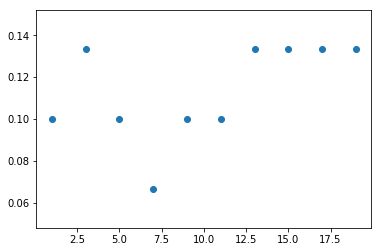

In [294]:
plt.scatter(Kvalues, MSE)

# Naive Bayes with Iris Data

In [297]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [298]:
colnames = ['sepal length in cm ','sepal width in cm', 'petal length in cm', 'petal width in cm', 'class']
iris_df = pd.read_csv("iris.data", names= colnames)
X = iris_df.drop("class", axis=1)
y = iris_df[["class"]]

In [299]:
#Check the dataset
X.head(3)

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [300]:
y.head(3)

,class
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa


# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

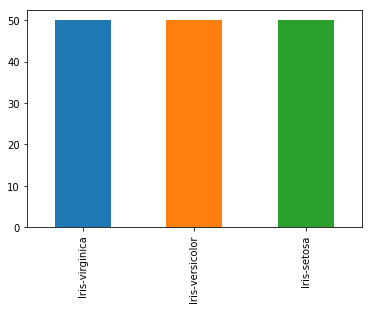

In [301]:
f=y["class"].value_counts()
f
f.plot(kind='bar')

In [302]:
#Drop Id variable from data

### Question 12 
Find Correlation among all variables and give your insights 

In [303]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

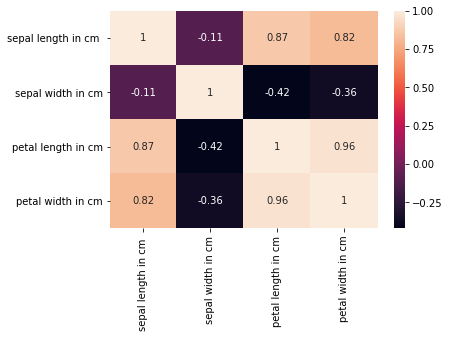

In [304]:
corr = X.corr()
sns.heatmap(corr, annot=True)

Ans) We have high correlation between petal length in cm & sepal length in cm

Also We have high correlation between petal width in cm & sepal length in cm

### Split data in Training and test set in 80:20.

In [305]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Question 13 
Do Feature Scaling 

In [306]:
# Use StandardScaler or similar methods

### Question 14 
Train and Fit NaiveBayes Model

In [307]:
#Fit the model
model = MultinomialNB()
model.fit(X_train, y_train)
print(model)

MultinomialNB(alpha=1.0, class_prior=None, fit_prior=True)


In [308]:
#Predict
predicted = model.predict(X_test)
predicted

array(['Iris-virginica', 'Iris-virginica', 'Iris-setosa',
       'Iris-virginica', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-setosa', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-virginica', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-virginica'], dtype='<U15')

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [309]:
# show Confusion Matrix
metrics.confusion_matrix(predicted, y_test)

array([[ 7,  0,  0],
       [ 0,  8,  1],
       [ 0,  4, 10]], dtype=int64)

In [314]:
model_score = model.score(X_test, y_test)
print("Accuracy is : ",model_score)

Accuracy is :  0.8333333333333334


In [315]:
y_predictProb = model.predict_proba(X_test)

In [ ]:
# show accuracy

In [ ]:
#Show precision and Recall metrics

# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [ ]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [ ]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [ ]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [ ]:
# use from sklearn.svm import SVC

In [ ]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [ ]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [ ]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [ ]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [ ]:
gs.fit(X_train_scaled, y_train) 

In [ ]:
gs.best_estimator_

In [ ]:
gs.best_score_ 